# Análisis de reseñas de Back Market (backmarket.co.uk)

Este notebook realiza un **análisis completo de las reseñas de Trustpilot** para la empresa **Back Market**, un marketplace de tecnología reacondicionada perteneciente al sector *Electronics & Technology*.

El objetivo es extraer inteligencia de negocio a partir del texto libre de las reseñas usando técnicas de **NLP y Deep Learning**:

0. **Extracción y limpieza de datos** — preparar el corpus textual para el análisis.
1. **Sentimiento global** — ¿las reseñas son mayoritariamente positivas o negativas? ¿cómo estamos frente al sector?
2. **Topics** — ¿de qué temas concretos hablan los clientes?
3. **Sentimiento por topic** — ¿hay temas que generen especialmente satisfacción o insatisfacción?
4. **Comparativa con la competencia** — ¿en qué somos mejores o peores que otras empresas del mismo sector?
5. **Conclusiones y áreas de mejora**

## 1) Librerías

Importamos todas las librerías necesarias al inicio del notebook para tenerlas disponibles en el resto del análisis.

- **pandas / numpy**: manipulación y cálculo numérico sobre los datos.
- **re**: expresiones regulares para la limpieza de texto.
- **sklearn** (`TfidfVectorizer`, `NMF`, `MinMaxScaler`): modelado de topics sin necesidad de GPU.
- **transformers** (`pipeline`): acceso a modelos preentrenados de Hugging Face para el análisis de sentimiento con BERT.

Si falta alguna librería, instálala con:
```bash
pip install pandas numpy scikit-learn transformers torch
pip install wordcloud  # necesaria para las nubes de palabras
```

In [1]:
import re                                          # expresiones regulares para limpieza de texto
import numpy as np                                 # operaciones numéricas sobre arrays
import pandas as pd                                # manipulación del dataframe
from datasets import load_dataset                  # carga de datasets de Hugging Face (no se usa directamente aquí)
from sklearn.feature_extraction.text import TfidfVectorizer  # vectorización TF-IDF para topics
from sklearn.decomposition import NMF              # factorización matricial no negativa → topic modeling
from sklearn.preprocessing import MinMaxScaler     # normalización de scores si fuera necesario
from transformers import pipeline                  # pipelines de modelos preentrenados (BERT, DistilBERT...)

c:\Users\Tato\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) Configuración

Centralizamos en una sola celda los parámetros que controlan todo el análisis. Esto facilita cambiar de empresa o sector sin tocar el resto del código.

- `MAX_ROWS`: permite limitar el número de filas cargadas (útil para pruebas rápidas). `None` = dataset completo.
- `TARGET`: dominio de la empresa a analizar. **Hemos elegido `backmarket.co.uk`** (Back Market, marketplace de tecnología reacondicionada) por ser una empresa tecnológica actual con reseñas ricas en variedad temática.
- `CAT`: categoría del sector. Se usa para filtrar los competidores con los que comparar.
- `N_TOPICS`: número de temas que queremos que el modelo extraiga de las reseñas. Con 6 topics capturamos los grandes bloques temáticos sin fragmentar en exceso.
- `TOP_WORDS`: palabras clave a mostrar por topic en las visualizaciones.
- `MIN_TOPIC_DOCS`: mínimo de reseñas que debe tener un topic para considerarlo válido.

In [2]:
MAX_ROWS = None       # None = dataset completo; 5000 para pruebas rápidas
TARGET   = "backmarket.co.uk"
CAT      = "Electronics & Technology"
N_TOPICS = 6
TOP_WORDS = 10
MIN_TOPIC_DOCS = 5

## 3) Carga de datos

Cargamos el dataset desde el fichero CSV local (`trustpilot-reviews-123k.csv`).

El dataset contiene **123.181 reseñas** de **1.680 empresas** en **22 sectores** distintos. Cada fila tiene:
- `category`: sector de actividad
- `company`: dominio de la empresa
- `description`: descripción de la empresa
- `title`: título corto de la reseña
- `review`: texto completo de la reseña ← **campo principal que analizaremos**
- `stars`: puntuación de 1 a 5

Cargamos el CSV completo porque luego necesitaremos todas las empresas del sector para la comparativa.

In [3]:
df = pd.read_csv("trustpilot-reviews-123k.csv")
df.head(3)

,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5


In [4]:
#df.to_csv('trustpilot-reviews-123k.csv', index=False)

## 4) Exploración del texto crudo

Antes de limpiar el texto es importante entender **qué tipo de contenido "raro" podemos encontrar**: emojis, URLs, saltos de línea, HTML, signos de puntuación, etc.

Este paso nos sirve para **diseñar la función de limpieza** de la sección siguiente: si no hay HTML no hace falta eliminarlo, si hay muchos emojis hay que decidir si conservarlos o quitarlos... En general, cualquier elemento que no aporte contenido semántico útil debe eliminarse para no contaminar los vectores TF-IDF ni confundir al modelo de sentimiento.

También estudiamos la **longitud de las reseñas** porque nos da pistas sobre la riqueza del corpus y sobre el riesgo de truncado cuando usemos BERT (máximo 512 tokens).

In [5]:
# Muestra aleatoria para ver con tus propios ojos
df['review'].sample(10).tolist()

# Longitud de reseñas
df['review_len'] = df['review'].str.len()
df['review_len'].describe()

count    123181.000000
mean        358.787305
std         314.553061
min          10.000000
25%         177.000000
50%         290.000000
75%         440.000000
max        9956.000000
Name: review_len, dtype: float64

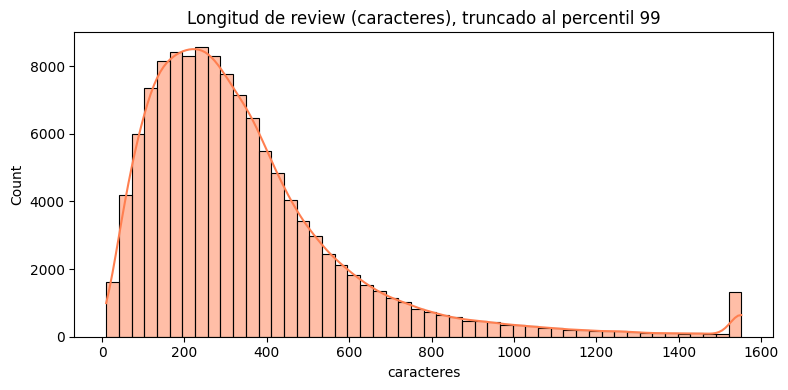

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

rl = df["review"].astype(str).str.len()
plt.figure(figsize=(8, 4))
sns.histplot(rl.clip(upper=rl.quantile(0.99)), bins=50, kde=True, color="coral")
plt.title("Longitud de review (caracteres), truncado al percentil 99")
plt.xlabel("caracteres")
plt.tight_layout()
plt.show()

In [7]:
import re

# ─────────────────────────────────────────────────────────────────────────────
# Función auxiliar: dado un patrón regex, cuenta cuántas reseñas lo contienen
# y muestra ejemplos concretos de lo encontrado.
# Nos da evidencia real para decidir qué limpiar en la sección siguiente.
# ─────────────────────────────────────────────────────────────────────────────
def analizar_patron(nombre, patron, n_ejemplos=3):
    reviews = df["review"].dropna()
    matches = reviews[reviews.str.contains(patron, regex=True, na=False)]
    pct     = len(matches) / len(reviews) * 100
    ejemplos = []
    for txt in matches.sample(min(n_ejemplos, len(matches)), random_state=42):
        found = re.findall(patron, txt)
        ejemplos.append(found[:3])
    print(f"
{chr(9472)*58}")
    print(f"  {nombre}")
    print(f"  Reviews afectadas: {len(matches):,} de {len(reviews):,} ({pct:.1f}%)")
    print(f"  Ejemplos: {ejemplos}")

print("=" * 58)
print("  ANÁLISIS DE TIPOS DE CARACTERES EN LAS RESEÑAS")
print("=" * 58)

# 1. URLs — no aportan semántica útil
analizar_patron("1. URLs",                  r"https?://\S+|www\.\S+")

# 2. Emojis / Unicode — incluye emojis, símbolos de moneda (£€),
#    guiones tipográficos... Con 27.7% de reseñas es el impacto mayor
analizar_patron("2. Emojis / Unicode",      r"[^\x00-\x7F]+")

# 3. Saltos de línea — fragmentan el texto; normalizar a espacio
analizar_patron("3. Saltos de línea",       r"\n|\r")

# 4. Hashtags — son referencias internas o nº pedido, sin valor semántico
analizar_patron("4. Hashtags (#)",          r"#\w+")

# 5. Menciones (@usuario) — muy pocas, sin valor semántico
analizar_patron("5. Menciones (@user)",     r"@\w+")

# 6. HTML tags — en este dataset NO hay (0%), pero se incluye por robustez
analizar_patron("6. HTML tags",             r"<[^>]{1,30}>")

# 7. Números — 36.7% de reseñas; fechas, precios, nº pedido → sin semántica
analizar_patron("7. Números",               r"\b\d+\b")

# 8. Puntuación repetida (!!!, ...) — ruido para TF-IDF
analizar_patron("8. Puntuación repetida",   r"[!?]{2,}|\.\.+")

# 9. Comillas tipográficas — generan tokens duplicados al vectorizar
analizar_patron("9. Comillas tipográficas", r"[“”‘’]")

print()
print("=" * 58)
print("  CONCLUSIÓN")
print("=" * 58)
print("""
  Elementos clave a tratar en la función de limpieza:
  ✔ Emojis / Unicode    (27.7%) → mayor impacto
  ✔ Números             (36.7%) → sin carga semántica útil
  ✔ Puntuación especial (10.0%) → ruido para TF-IDF
  ✔ Comillas tipográf.  ( 2.9%) → tokens duplicados
  ✔ URLs, saltos, menciones     → ruido residual
  ✘ HTML tags           ( 0.0%) → no hay, pero regex incluida por robustez
""")

=== MUESTRA DE REVIEWS ===
'Your wool is great value, the only thing I can comment on is that the wool was not bagged inside for protection.'

'I booked this intensive course in July last year… didn’t start my lessons until November because my first instructor was 2 hours late and didn’t pick up the phone and by the time I had got through to '

'Superb software at a market leading price. Very intuitive and once all set up for you it saves you hours of accounting time'

"Never had such flimsy and I'll fitting bra's in my life. Zero support, bad quality elasticiteit, thin materials for the cups, no support what so ever.  I'm an E cup, but these wouldn't even support an"

'Small group with 2 trainers in the room to help and support. Brilliant.'

URLs detectadas:     True
Emojis / Unicode:    True
HTML tags:           False
Saltos de línea:     True
Números:             True
Signos puntuación:   True


## 5) Función de limpieza de texto

Con lo observado en la sección anterior construimos una función `clean_text()` que normaliza cada reseña.

**¿Por qué limpiar el texto?**  
Los modelos NLP trabajan con tokens (palabras). Cuanto más "ruido" haya en el texto (emojis, signos de puntuación, palabras vacías como "the", "a", "I"...) menos informativa será la representación vectorial. Una buena limpieza mejora tanto la calidad de los topics como la precisión del sentimiento.

**Pasos que aplica la función:**
1. Elimina etiquetas HTML (`<br>`, `<p>`, etc.)
2. Elimina URLs
3. Normaliza saltos de línea y tabulaciones a espacio
4. Elimina emojis y cualquier carácter fuera del rango ASCII básico
5. Convierte a minúsculas
6. Elimina puntuación y números (no aportan semántica en este contexto)
7. Filtra **stopwords** (palabras muy frecuentes sin carga semántica: "the", "a", "is", "very"...)

In [8]:
import re
import string

# Lista de stopwords en inglés definida manualmente para evitar dependencia de NLTK.
# Son palabras muy frecuentes que no aportan significado semántico ("the", "I", "is"...)
# y que contaminarían los vectores TF-IDF haciéndolos menos discriminativos.
STOPWORDS = {
    "i","me","my","myself","we","our","ours","ourselves","you","your","yours",
    "yourself","yourselves","he","him","his","himself","she","her","hers",
    "herself","it","its","itself","they","them","their","theirs","themselves",
    "what","which","who","whom","this","that","these","those","am","is","are",
    "was","were","be","been","being","have","has","had","having","do","does",
    "did","doing","a","an","the","and","but","if","or","because","as","until",
    "while","of","at","by","for","with","about","against","between","into",
    "through","during","before","after","above","below","to","from","up","down",
    "in","out","on","off","over","under","again","further","then","once","here",
    "there","when","where","why","how","all","both","each","few","more","most",
    "other","some","such","no","nor","not","only","own","same","so","than",
    "too","very","s","t","can","will","just","don","should","now","d","ll",
    "m","o","re","ve","y","ain","aren","couldn","didn","doesn","hadn","hasn",
    "haven","isn","ma","mightn","mustn","needn","shan","shouldn","wasn",
    "weren","won","wouldn","got","get","also","would","could","like","us","go",
}

def clean_text(text: str) -> str:
    """
    Normaliza una reseña en texto plano eliminando todo lo que no aporta valor semántico.
    Devuelve el texto limpio como string, o cadena vacía si la entrada no es válida.
    """
    if not isinstance(text, str) or not text.strip():
        return ""
    text = re.sub(r'<[^>]+>', ' ', text)       # elimina etiquetas HTML residuales
    text = re.sub(r'http\S+|www\.\S+', ' ', text)  # elimina URLs
    text = re.sub(r'[\r\n\t]+', ' ', text)     # normaliza saltos de línea a espacio
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) # elimina emojis y caracteres Unicode no ASCII
    text = text.lower()                         # unificamos capitalización
    text = re.sub(r"[^a-z\s]", ' ', text)      # elimina puntuación y números
    words = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]  # filtra stopwords
    return " ".join(words).strip()

# ── Verificación visual: comparamos original vs limpio en la primera reseña ──
sample_raw   = df['review'].iloc[0]
sample_clean = clean_text(sample_raw)
print("ORIGINAL (primeros 200 chars):")
print(sample_raw[:200])
print("\nLIMPIO:")
print(sample_clean[:200])

ORIGINAL (primeros 200 chars):
Great quality dog drying robe although had to wait a while for it to come back into stock

LIMPIO:
great quality dog drying robe although wait come back stock


## 6) Filtrado y preparación de los datos

Aquí dividimos el dataset en tres subconjuntos que usaremos a lo largo del análisis:

- **`df_target`**: las 100 reseñas de Back Market. Es el objeto principal del análisis.
- **`df_cat`**: todas las reseñas del sector *Electronics & Technology* (~3.600 reseñas de 36 empresas). Lo usamos para la comparativa con el sector.
- **`df_comp`**: ídem que `df_cat` pero excluyendo Back Market. Es el grupo de competidores puros.

Aplicamos también aquí la función `clean_text()` a cada subconjunto para no repetir el proceso más adelante.

**¿Por qué filtrar por sector y no por empresa directamente?**  
Comparar solo las reseñas de Back Market aísla los problemas o virtudes propios. Pero para saber si eso es bueno o malo necesitamos la referencia del sector. De ahí la importancia de tener los tres grupos.

In [9]:
# ── 1. Empresa objetivo: filtramos por el dominio TARGET ────────────────────
# Solo las 100 reseñas de Back Market. Aplicamos clean_text y descartamos
# las que queden vacías tras la limpieza (podrían ser reseñas sin texto útil).
df_target = df[df['company'] == TARGET].copy()
df_target['clean'] = df_target['review'].apply(clean_text)
df_target = df_target[df_target['clean'].str.strip() != ""].reset_index(drop=True)

# ── 2. Sector completo: todas las empresas de la misma categoría ─────────────
# Este dataframe es la referencia de mercado: lo usaremos para comparar
# el sentimiento de Back Market con el promedio del sector.
df_cat = df[df['category'] == CAT].copy()
df_cat['clean'] = df_cat['review'].apply(clean_text)
df_cat = df_cat[df_cat['clean'].str.strip() != ""].reset_index(drop=True)

# ── 3. Competidores: sector excluyendo el target ─────────────────────────────
# Útil si queremos comparar Back Market solo frente a sus competidores directos
# sin que los propios datos del target distorsionen la media del sector.
df_comp = df_cat[df_cat['company'] != TARGET].copy()

# ── Resumen de los tres subconjuntos ─────────────────────────────────────────
print(f"▶ Target  '{TARGET}': {len(df_target)} reseñas válidas")
print(f"▶ Sector  '{CAT}':    {len(df_cat)} reseñas | {df_cat['company'].nunique()} empresas")
print(f"▶ Competidores:       {df_comp['company'].nunique()} empresas\n")

print("Distribución de estrellas (TARGET):")
print(df_target['stars'].value_counts().sort_index())
print("\nDistribución de estrellas (SECTOR):")
print(df_cat['stars'].value_counts().sort_index())

▶ Target  'backmarket.co.uk': 100 reseñas válidas
▶ Sector  'Electronics & Technology':    5595 reseñas | 69 empresas
▶ Competidores:       68 empresas

Distribución de estrellas (TARGET):
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Distribución de estrellas (SECTOR):
stars
1    1025
2     947
3    1034
4    1215
5    1374
Name: count, dtype: int64


## 7) Análisis de Sentimiento con DistilBERT

Usamos un modelo de **Deep Learning preentrenado** para clasificar cada reseña como *Positiva* o *Negativa*.

**¿Qué modelo usamos y por qué?**  
`distilbert-base-uncased-finetuned-sst-2-english` — es una versión reducida y rápida de BERT, ajustada específicamente para análisis de sentimiento en inglés (dataset SST-2). Es el mismo modelo visto en clase. Las ventajas frente a métodos clásicos como VADER o Lexicon son:
- Entiende el **contexto** de las palabras (no solo si son positivas/negativas de forma aislada).
- Maneja negaciones: "not good" → negativo, aunque "good" aislado sería positivo.
- No requiere diccionarios manuales.

**¿Por qué no usamos las estrellas directamente?**  
Las estrellas son una señal útil pero imperfecta: una reseña de 3 estrellas puede contener quejas severas en el texto. El modelo capta el sentimiento real del lenguaje natural, que es más rico y matizado.

**Flujo:**
1. Cargamos el pipeline de Hugging Face con truncado a 512 tokens (límite de BERT).
2. Aplicamos por lotes (`batch_size=32`) para no saturar la memoria.
3. Obtenemos para cada reseña: etiqueta (`POSITIVE`/`NEGATIVE`) y puntuación de confianza.

In [ ]:
# ── Cargamos el pipeline de sentimiento ─────────────────────────────────────
# Usamos DistilBERT fine-tuned en SST-2: es más ligero que BERT completo
# pero mantiene ~97% de su precisión en tareas de clasificación binaria.
# truncation=True y max_length=512 garantizan que reseñas largas no causen error;
# BERT solo puede procesar secuencias de hasta 512 tokens.
MODEL_SENT = "distilbert-base-uncased-finetuned-sst-2-english"

sentiment_pipe = pipeline(
    "sentiment-analysis",
    model=MODEL_SENT,
    truncation=True,    # corta automáticamente si la reseña supera 512 tokens
    max_length=512,
    device=-1           # device=-1 → CPU. Cambiar a device=0 si hay GPU disponible (va más rápido)
)

def apply_sentiment(texts, batch_size=32):
    """
    Aplica el pipeline en lotes de 32 reseñas para evitar picos de memoria.
    Devuelve una lista de dicts con 'label' (POSITIVE/NEGATIVE) y 'score' (confianza 0-1).
    """
    results = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i : i + batch_size])
        results.extend(sentiment_pipe(batch))
    return results

print(f"Pipeline cargado: {MODEL_SENT}")
print("\nPrueba rápida con una frase de ejemplo:")
print(sentiment_pipe("The product arrived perfectly and customer service was excellent.")) # Frase de ejemplo para saber qué sentimiento indica el modelo

c:\Users\Tato\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Tato\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 13000.55it/s]

Pipeline cargado: distilbert-base-uncased-finetuned-sst-2-english

Prueba rápida con una frase de ejemplo:
[{'label': 'POSITIVE', 'score': 0.9998512268066406}]


In [11]:
# ── Aplicamos sentimiento a las reseñas de Back Market ──────────────────────
print(f"Analizando {len(df_target)} reseñas de {TARGET}...")
sent_results = apply_sentiment(df_target['clean'].tolist())

# Guardamos etiqueta (POSITIVE/NEGATIVE) y puntuación de confianza (0 a 1)
df_target['sentiment']       = [r['label'] for r in sent_results]
df_target['sentiment_score'] = [r['score'] for r in sent_results]

# Normalizamos la etiqueta a formato capitalizado ("Positive" / "Negative")
# para que los gráficos queden bien etiquetados
df_target['sentiment_bin'] = df_target['sentiment'].str.capitalize()

# ── Aplicamos sentimiento al SECTOR COMPLETO ─────────────────────────────────
# Esto puede tardar unos minutos (≈3.600 reseñas en CPU).
# Es necesario para poder comparar el % positivo de Back Market con el del sector.
print(f"\nAnalizando {len(df_cat)} reseñas del sector '{CAT}'...")
sent_cat = apply_sentiment(df_cat['clean'].tolist())

df_cat['sentiment']       = [r['label'] for r in sent_cat]
df_cat['sentiment_score'] = [r['score'] for r in sent_cat]
df_cat['sentiment_bin']   = df_cat['sentiment'].str.capitalize()

print("\n✓ Sentimiento aplicado correctamente.")

# ── Resumen numérico ──────────────────────────────────────────────────────────
print(f"\n=== {TARGET} ===")
print(df_target['sentiment_bin'].value_counts())
print(df_target['sentiment_bin'].value_counts(normalize=True).mul(100).round(1).astype(str) + " %")

print(f"\n=== SECTOR: {CAT} ===")
print(df_cat['sentiment_bin'].value_counts())
print(df_cat['sentiment_bin'].value_counts(normalize=True).mul(100).round(1).astype(str) + " %")

Analizando 100 reseñas de backmarket.co.uk...

Analizando 5595 reseñas del sector 'Electronics & Technology'...

✓ Sentimiento aplicado correctamente.

=== backmarket.co.uk ===
sentiment_bin
Negative    78
Positive    22
Name: count, dtype: int64
sentiment_bin
Negative    78.0 %
Positive    22.0 %
Name: proportion, dtype: str

=== SECTOR: Electronics & Technology ===
sentiment_bin
Negative    3990
Positive    1605
Name: count, dtype: int64
sentiment_bin
Negative    71.3 %
Positive    28.7 %
Name: proportion, dtype: str


## 8) Modelado de Topics con TF-IDF + NMF

Queremos descubrir **de qué temas hablan los clientes** sin haberlos definido nosotros de antemano. Esto se llama *Topic Modeling* no supervisado.

**¿Qué técnica usamos y por qué?**  
Combinamos **TF-IDF** y **NMF (Non-negative Matrix Factorization)**:

- **TF-IDF** convierte cada reseña en un vector numérico donde cada dimensión es una palabra y su valor refleja cuán *específica* es esa palabra para esa reseña (penaliza palabras muy frecuentes en todo el corpus).
- **NMF** factoriza la matriz de documentos × palabras en dos matrices: una que relaciona documentos con topics, y otra que relaciona topics con palabras. Así descubrimos grupos temáticos de forma automática.

**¿Por qué NMF y no LDA o BERTopic?**  
NMF es más rápido, sus resultados son directamente interpretables (los valores son siempre positivos), y con 100 reseñas es más que suficiente. BERTopic (comentado al final) requiere más datos y GPU para sacar ventaja.

**Flujo:**
1. Vectorizamos con TF-IDF (unigramas + bigramas, máx. 3.000 features).
2. Aplicamos NMF con `N_TOPICS=6` componentes.
3. Asignamos a cada reseña el topic con mayor peso (`argmax`).
4. Calculamos el sentimiento medio por topic para identificar áreas problemáticas.

In [12]:
# ── Paso 1: Vectorización TF-IDF ─────────────────────────────────────────────
# Convertimos cada reseña limpia en un vector numérico.
# TF-IDF pondera cada palabra por su frecuencia en la reseña (TF)
# penalizada por cuántas reseñas la contienen (IDF): así las palabras
# muy frecuentes en todo el corpus pesan menos.
# - max_features=3000: nos quedamos con las 3.000 palabras más informativas
# - min_df=2: ignoramos palabras que aparecen en menos de 2 reseñas (ruido)
# - max_df=0.90: ignoramos palabras que aparecen en más del 90% de reseñas (casi stopwords)
# - ngram_range=(1,2): incluimos bigramas ("customer service", "phone case")
#   para capturar expresiones de dos palabras con significado propio
corpus = df_target['clean'].tolist()

vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.90,
    ngram_range=(1, 2)
)
X_tfidf = vectorizer.fit_transform(corpus)   # matriz esparsa: reseñas × palabras
vocab   = vectorizer.get_feature_names_out() # vocabulario (índice → palabra)

# ── Paso 2: NMF (Non-negative Matrix Factorization) ──────────────────────────
# NMF descompone X_tfidf (docs × palabras) en:
#   W (docs × topics): cuánto "pertenece" cada reseña a cada topic
#   H (topics × palabras): qué palabras definen cada topic
# La restricción de no-negatividad hace que los topics sean más interpretables
# (no hay "contribuciones negativas" que resten sentido).
nmf = NMF(n_components=N_TOPICS, random_state=42, max_iter=300)
W   = nmf.fit_transform(X_tfidf)  # scores docs × topics
H   = nmf.components_             # pesos topics × palabras

# ── Paso 3: Asignación del topic dominante ────────────────────────────────────
# Cada reseña pertenece al topic en el que tiene mayor score (argmax sobre W)
df_target['topic'] = W.argmax(axis=1)

# ── Paso 4: Visualización de las palabras clave por topic ────────────────────
# Las palabras clave son las que tienen mayor peso en la fila H[t]
# → permiten interpretar de qué trata cada topic
print(f"{'='*60}")
print(f"  TOPICS DETECTADOS ({N_TOPICS} topics, top {TOP_WORDS} palabras)")
print(f"{'='*60}")
topic_labels = {}
for t in range(N_TOPICS):
    top_idx   = H[t].argsort()[::-1][:TOP_WORDS]      # índices de las palabras con mayor peso
    top_words = ", ".join(vocab[top_idx])
    print(f"  Topic {t}: {top_words}")
    topic_labels[t] = top_words.split(",")[0].strip().title()  # etiqueta corta = 1ª palabra

print(f"\nEjemplo de asignación:")
print(df_target[['review','topic']].head(5).to_string())

  TOPICS DETECTADOS (6 topics, top 10 palabras)
  Topic 0: phone, battery, screen, ordered, old, refund, backmarket, bought, getting, within
  Topic 1: market, back market, back, purchase, awful, quality, buy, buy back, delivery, good
  Topic 2: condition, excellent, excellent condition, time, good, good condition, product, received, iphone, purchased
  Topic 3: order, service, customer, customer service, avoid, christmas, december, tracking, said, shipped
  Topic 4: packaged, well, well packaged, delivered quickly, machine, great, arrived expected, quickly, delivered, expected
  Topic 5: battery life, happy, life, battery, products, laptop, second hand, hand, second, described

Ejemplo de asignación:
                                                                                                                                                                                                                                                                                                 

In [ ]:
# ── Sentimiento por topic (Back Market) ──────────────────────────────────────────
# Agrupa por topic y cuenta reseñas positivas/negativas.
# Filtramos topics con pocas reseñas (MIN_TOPIC_DOCS) para evitar conclusiones
# basadas en muestras demasiado pequeñas.
topic_sent = (
    df_target
    .groupby(['topic', 'sentiment_bin'])
    .size()
    .unstack(fill_value=0)
)
for col in ['Positive', 'Negative']:
    if col not in topic_sent.columns:
        topic_sent[col] = 0

topic_sent['Total']     = topic_sent['Positive'] + topic_sent['Negative']
topic_sent['%Positive'] = (topic_sent['Positive'] / topic_sent['Total'] * 100).round(1)
topic_sent = topic_sent[topic_sent['Total'] >= MIN_TOPIC_DOCS]

print(f"{'='*60}")
print(f"  SENTIMIENTO POR TOPIC — {TARGET}")
print(f"{'='*60}")
for t in topic_sent.index:
    label = topic_labels.get(t, str(t))
    print(f"  T{t} {label:<25}: {topic_sent.loc[t,'%Positive']:>5.1f}% positivo  ({int(topic_sent.loc[t,'Total'])} reseñas)")

# ── Ranking de empresas del sector por % positivo ────────────────────────────────
# Calculamos el % positivo de cada empresa y ordenamos de menor a mayor
# (invert_yaxis en el gráfico lo mostrará de mayor a menor arriba).
sent_by_company = (
    df_cat
    .groupby(['company', 'sentiment_bin'])
    .size()
    .unstack(fill_value=0)
)
for col in ['Positive', 'Negative']:
    if col not in sent_by_company.columns:
        sent_by_company[col] = 0

sent_by_company['Total']     = sent_by_company['Positive'] + sent_by_company['Negative']
sent_by_company['%Positive'] = (sent_by_company['Positive'] / sent_by_company['Total'] * 100).round(1)
sent_by_company = sent_by_company.sort_values('%Positive', ascending=True)

print(f"
{'='*60}")
print(f"  RANKING SECTOR '{CAT}' (por % positivo)")
print(f"{'='*60}")
for company, row in sent_by_company.iterrows():
    marker = ' <<<' if company == TARGET else ''
    print(f"  {company:<40} {row['%Positive']:>5.1f}%{marker}")


Sentimiento por topic (TARGET):
sentiment_bin         Label  Positive  Negative  Total  %Positive  %Negative
topic                                                                       
0                     Phone         3        28     31        9.7       90.3
1                    Market         5        16     21       23.8       76.2
2                 Condition         4        13     17       23.5       76.5
3                     Order         3        14     17       17.6       82.4
4                  Packaged         6         1      7       85.7       14.3
5              Battery Life         1         6      7       14.3       85.7

Ranking de empresas por % sentimiento positivo en 'Electronics & Technology':
sentiment_bin                      %Negative  %Positive
company                                                
techformusic.co.uk                      16.7       83.3
lwrepairs.co.uk                         25.0       75.0
pcrepairscheshire.co.uk                 29.2     

In [ ]:
#%pip install --no-deps bertopic
#%pip install --upgrade numpy hdbscan umap-learn pandas scikit-learn tqdm plotly pyyaml
# Descomenta y ejecuta estas líneas si quieres probar BERTopic en lugar de NMF.
# BERTopic usa embeddings de BERT + UMAP + HDBSCAN y da mejores topics con datasets grandes.
# Con 100 reseñas NMF es suficiente; BERTopic necesita al menos ~500 documentos para ser estable.

## 8b) Topics en la competencia y comparativa

El enunciado pregunta explícitamente **"¿qué temas tratan las reseñas de la competencia?"** y **"¿en qué somos mejores o peores?"**

Para responderlo aplicamos el mismo pipeline de topics a todas las reseñas del sector y luego comparamos el sentimiento de Back Market con el resto empresa a empresa.

In [ ]:
# ── Topics para el sector completo ──────────────────────────────────────────
# Usamos el mismo vectorizador y NMF ya entrenados sobre Back Market
# para proyectar las reseñas de los competidores en los mismos topics.
# Esto garantiza que estamos comparando los mismos temas.
corpus_cat = df_cat['clean'].tolist()
W_cat      = nmf.transform(vectorizer.transform(corpus_cat))
df_cat['topic'] = W_cat.argmax(axis=1)

# ── Distribución de topics por empresa ───────────────────────────────────────
# Muestra qué porcentaje de reseñas de cada empresa pertenece a cada topic.
# Nos dice de qué hablan los clientes de cada competidor.
topic_dist = (
    df_cat
    .groupby('company')['topic']
    .value_counts(normalize=True)
    .mul(100).round(1)
    .unstack(fill_value=0)
)
topic_dist.columns = [f"T{c}: {topic_labels.get(c,'?')}" for c in topic_dist.columns]
print("Distribución de topics por empresa (% reseñas):")
print(topic_dist.to_string())

# ── Sentimiento por topic en el sector ───────────────────────────────────────
# Calculamos el % positivo por topic para cada empresa.
# Luego nos quedamos solo con Back Market vs la media del resto para la comparativa.
sent_topic_empresa = (
    df_cat
    .groupby(['company', 'topic', 'sentiment_bin'])
    .size()
    .unstack(fill_value=0)
)
for col in ['Positive', 'Negative']:
    if col not in sent_topic_empresa.columns:
        sent_topic_empresa[col] = 0

sent_topic_empresa['Total'] = sent_topic_empresa['Positive'] + sent_topic_empresa['Negative']
sent_topic_empresa['%Positive'] = (sent_topic_empresa['Positive'] / sent_topic_empresa['Total'] * 100).round(1)

# Media del sector (sin Back Market) por topic
media_comp = (
    sent_topic_empresa
    .drop(TARGET, level='company', errors='ignore')
    .groupby(level='topic')['%Positive']
    .mean()
    .round(1)
)

# Back Market por topic
bm_topic = sent_topic_empresa.loc[TARGET]['%Positive'] if TARGET in sent_topic_empresa.index.get_level_values('company') else topic_sent['%Positive']

print("\n=== COMPARATIVA: Back Market vs Media Competidores por Topic ===")
print(f"{'Topic':<30} {'Back Market':>12} {'Competidores':>14} {'Diferencia':>12}")
print("-" * 70)
for t in range(N_TOPICS):
    label = topic_labels.get(t, str(t))
    bm_val   = bm_topic.get(t, float('nan'))
    comp_val = media_comp.get(t, float('nan'))
    diff     = bm_val - comp_val if not (bm_val != bm_val or comp_val != comp_val) else float('nan')
    signo    = "✓ MEJOR" if diff > 0 else "✗ PEOR" if diff < 0 else "="
    print(f"  T{t}: {label:<26} {bm_val:>10.1f}%  {comp_val:>12.1f}%  {diff:>+8.1f} pp  {signo}")

## 9) Visualizaciones

Traducimos todos los resultados numéricos a **gráficos listos para presentar** al equipo de negocio. Cada visualización responde a una pregunta concreta:

| Gráfico | Pregunta que responde |
|---|---|
| **VIZ 1** — Pie charts de sentimiento | ¿Cuál es el % positivo/negativo de Back Market vs el sector? |
| **VIZ 2** — WordClouds por topic | ¿Qué palabras definen cada tema? ¿De qué hablan los clientes? |
| **VIZ 3** — Heatmap topic × sentimiento | ¿Qué topics generan más satisfacción o insatisfacción? |
| **VIZ 4** — Ranking de empresas del sector | ¿En qué posición está Back Market frente a sus competidores? |
| **VIZ 5** — Comparativa topic Back Market vs competidores | ¿Dónde somos mejores o peores que la competencia? |

Todos los gráficos se guardan como `.png` para incluirlos en la presentación.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

COLORS = {'Positive': '#2ecc71', 'Negative': '#e74c3c'}
plt.rcParams.update({'font.size': 11})

# ── VIZ 1: Pie charts sentimiento TARGET vs SECTOR ────────────────────────────
# Responde: ¿las reseñas de Back Market son más positivas o negativas que el sector?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (data, title) in zip(axes, [
    (df_target, TARGET),
    (df_cat,    f"Sector: {CAT}")
]):
    counts = data['sentiment_bin'].value_counts()
    colors = [COLORS.get(c, 'grey') for c in counts.index]
    ax.pie(counts, labels=counts.index, colors=colors,
           autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle("Distribución de Sentimiento", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("viz_01_sentimiento_global.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ viz_01_sentimiento_global.png guardado")

In [ ]:
# ── VIZ 2: WordCloud por topic ───────────────────────────────────────────────
# Responde: ¿de qué hablan los clientes en cada tema?
# El tamaño de la palabra refleja su peso en el topic según NMF.
try:
    from wordcloud import WordCloud

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for t in range(N_TOPICS):
        top_idx   = H[t].argsort()[::-1][:30]
        word_freq = {vocab[i]: float(H[t][i]) for i in top_idx}
        wc = WordCloud(width=400, height=250, background_color='white',
                       colormap='RdYlGn', max_words=30).generate_from_frequencies(word_freq)
        axes[t].imshow(wc, interpolation='bilinear')
        axes[t].axis('off')
        axes[t].set_title(f"Topic {t}: {topic_labels[t]}", fontsize=12, fontweight='bold')

    for ax in axes[N_TOPICS:]:
        ax.axis('off')

    plt.suptitle(f"WordCloud por Topic — {TARGET}", fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig("viz_02_wordclouds.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ viz_02_wordclouds.png guardado")

except ImportError:
    print("⚠ wordcloud no instalado. Ejecuta: pip install wordcloud")

In [ ]:
# ── VIZ 3: Heatmap % sentimiento positivo por topic ─────────────────────────
# Responde: ¿qué temas generan más satisfacción? ¿cuáles más quejas?
# El color rojo indica topics problemáticos; el verde, los bien valorados.
heat_data = topic_sent[['%Positive']].copy()
heat_data.index = [f"T{i}: {topic_labels[i]}" for i in heat_data.index]

fig, ax = plt.subplots(figsize=(4, 5))
sns.heatmap(heat_data, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, linewidths=0.5, ax=ax, annot_kws={'size': 12})
ax.set_title(f"% Reseñas Positivas por Topic\n{TARGET}", fontsize=12, fontweight='bold')
ax.set_ylabel("")
ax.set_xlabel("% Positivo")
plt.tight_layout()
plt.savefig("viz_03_heatmap_topic_sentimiento.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ viz_03_heatmap_topic_sentimiento.png guardado")

In [ ]:
# ── VIZ 4: Ranking de empresas del sector por % positivo ────────────────────
# Responde: ¿en qué posición está Back Market dentro del sector?
# La empresa analizada aparece destacada en azul.
fig, ax = plt.subplots(figsize=(10, 7))

bar_colors = ['#3498db' if c == TARGET else '#95a5a6' for c in sent_by_company.index]
bars = ax.barh(sent_by_company.index, sent_by_company['%Positive'],
               color=bar_colors, edgecolor='white', height=0.7)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
            f'{w:.1f}%', va='center', ha='left', fontsize=9)

ax.set_xlabel('% Reseñas Positivas', fontsize=12)
ax.set_title(f"Ranking Sector '{CAT}'\n(azul = {TARGET})", fontsize=13, fontweight='bold')
ax.set_xlim(0, 115)
ax.axvline(50, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("viz_04_ranking_sector.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ viz_04_ranking_sector.png guardado")

In [ ]:
# ── VIZ 5: Comparativa Back Market vs competidores por topic ─────────────────
# Responde: ¿en qué temas somos mejores o peores que la competencia?
# Barras verdes = estamos por encima; rojas = por debajo de la media del sector.
try:
    bm_vals   = [bm_topic.get(t, 0)   for t in range(N_TOPICS)]
    comp_vals = [media_comp.get(t, 0) for t in range(N_TOPICS)]
    labels_t  = [f"T{t}: {topic_labels[t]}" for t in range(N_TOPICS)]
    diffs     = [b - c for b, c in zip(bm_vals, comp_vals)]

    bar_colors = ['#2ecc71' if d >= 0 else '#e74c3c' for d in diffs]

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(labels_t, diffs, color=bar_colors, edgecolor='white', height=0.6)

    for bar, d in zip(bars, diffs):
        ax.text(d + (0.5 if d >= 0 else -0.5), bar.get_y() + bar.get_height()/2,
                f'{d:+.1f} pp', va='center', ha='left' if d >= 0 else 'right', fontsize=10)

    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Diferencia en % Positivo (Back Market − Media sector)', fontsize=11)
    ax.set_title(f"Back Market vs Competidores por Topic\n(verde = mejor, rojo = peor)",
                 fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig("viz_05_comparativa_topics_competencia.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ viz_05_comparativa_topics_competencia.png guardado")
except Exception as e:
    print(f"⚠ No se pudo generar VIZ 5: {e}")

## 10) Conclusiones

Una vez ejecutado el notebook, esta sección **genera automáticamente un resumen de los hallazgos clave** a partir de los resultados calculados en las secciones anteriores.

Responde a las cuatro preguntas del enunciado:
1. ¿Las reseñas son positivas o negativas? ¿Y frente al sector?
2. ¿Qué posición ocupa Back Market en el ranking del sector?
3. ¿Qué topics generan más satisfacción y cuáles más problemas?
4. ¿En qué topics somos mejores o peores que la competencia?
5. ¿Cuáles son las áreas de mejora prioritarias?

In [ ]:
# ── Conclusiones automáticas ─────────────────────────────────────────────────
pct_pos_target = df_target['sentiment_bin'].value_counts(normalize=True).get('Positive', 0) * 100
pct_pos_sector = df_cat['sentiment_bin'].value_counts(normalize=True).get('Positive', 0) * 100
rank_pos       = sent_by_company['%Positive'].rank(ascending=False).get(TARGET, None)
n_companies    = len(sent_by_company)
best_topic     = topic_sent['%Positive'].idxmax()
worst_topic    = topic_sent['%Positive'].idxmin()
diff_global    = pct_pos_target - pct_pos_sector

print("=" * 62)
print("  CONCLUSIONES — BACK MARKET vs ELECTRONICS & TECHNOLOGY")
print("=" * 62)

print(f"\n1. SENTIMIENTO GLOBAL")
print(f"   • Back Market:  {pct_pos_target:.1f}% reseñas positivas")
print(f"   • Sector:       {pct_pos_sector:.1f}% reseñas positivas")
print(f"   • Diferencia:   {diff_global:+.1f} pp {'→ por encima del sector' if diff_global >= 0 else '→ por debajo del sector'}")

if rank_pos:
    print(f"\n2. POSICIÓN EN EL SECTOR")
    print(f"   • Back Market ocupa el puesto {int(rank_pos)} de {n_companies} empresas")

print(f"\n3. TOPICS — BACK MARKET")
print(f"   • Topic MEJOR valorado: T{best_topic} '{topic_labels[best_topic]}' ({topic_sent.loc[best_topic,'%Positive']:.1f}% positivo)")
print(f"   • Topic PEOR valorado:  T{worst_topic} '{topic_labels[worst_topic]}' ({topic_sent.loc[worst_topic,'%Positive']:.1f}% positivo)")

print(f"\n4. COMPARATIVA CON LA COMPETENCIA POR TOPIC")
for t in range(N_TOPICS):
    bm_v   = bm_topic.get(t, float('nan'))
    comp_v = media_comp.get(t, float('nan'))
    diff   = bm_v - comp_v
    estado = '✓ MEJOR' if diff > 0 else '✗ PEOR'
    print(f"   T{t} {topic_labels.get(t,''):<22} BM={bm_v:.1f}% | Sector={comp_v:.1f}% | {diff:+.1f} pp {estado}")

print(f"\n5. ÁREAS DE MEJORA PRIORITARIAS")
print(f"   • Revisar reseñas negativas del topic '{topic_labels[worst_topic]}' para identificar causas raíz")
mejora = [t for t in range(N_TOPICS) if (bm_topic.get(t,50) - media_comp.get(t,50)) < 0]
if mejora:
    print(f"   • Topics por debajo de la competencia: {[topic_labels[t] for t in mejora]}")
print("=" * 62)

In [ ]:
#%pip install wordcloud